# Практическое задание №1
## Основы цифровой обработки сигналов: дискретизация, спектральный анализ, алиасинг

**Цель работы:**  
- Освоить базовые приёмы работы с библиотеками NumPy и Matplotlib в Jupyter Notebook.  
- Научиться генерировать различные типы сигналов и анализировать их спектры с помощью быстрого преобразования Фурье (БПФ).  
- Изучить эффект алиасинга и научиться правильно выбирать частоту дискретизации.  

**Необходимое ПО:**  
- Python 3 с установленными пакетами `numpy`, `matplotlib`, `scipy`, `ipywidgets` (для интерактива).  
- Jupyter Notebook / Google Colab.  

**Формат сдачи:**  
- Один Jupyter Notebook с выполненными заданиями, содержащий код, графики и текстовые ответы на вопросы.  
- Имя файла: `1_Фамилия.ipynb`.

## Часть 1. Знакомство с инструментарием

### 1.1. Импорт библиотек и создание временной оси

Выполните в первой ячейке:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

Создайте временную ось для сигнала длительностью 1 секунду с частотой дискретизации 1000 Гц (т.е. 1000 отсчётов в секунду). Выведите длину массива времени и шаг дискретизации.

In [2]:
fs = 1000          # частота дискретизации, Гц
T = 1              # длительность сигнала, с

t = np.linspace(0, T, int(fs * T), endpoint=False)  # временная ось

print(f"Длина массива времени: {len(t)} отсчётов")
print(f"Шаг дискретизации (период): {1/fs} с")


Длина массива времени: 1000 отсчётов
Шаг дискретизации (период): 0.001 с


**Вопрос 1:** Чему равен период дискретизации $T_s$? Как связаны частота дискретизации $f_s$ и период $T_s$?

Период дискретизации равен $T_s = 1/f_s = 1/1000 = 0.001$ с. Частота и период связаны формулой $f_s = 1/T_s$ (и, соответственно, $T_s=1/f_s$).

### 1.2. Генерация простых сигналов

Сгенерируйте и визуализируйте:
- Синусоидальный сигнал частотой 5 Гц, амплитудой 1.
- Сумму двух синусоид с частотами 5 и 12 Гц и одинаковыми амплитудами.
- Прямоугольный меандр частотой 2 Гц (используйте `signal.square`).

Для каждого сигнала постройте график временной зависимости (первые 0.5 секунды).

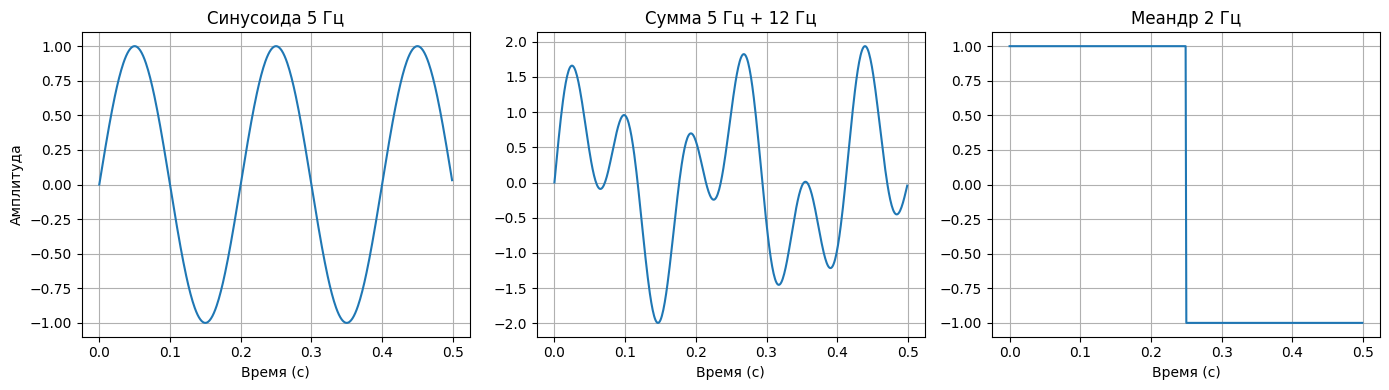

In [3]:
# Синусоида 5 Гц
f1 = 5
sin5 = np.sin(2 * np.pi * f1 * t)

# Сумма синусоид 5 и 12 Гц
f2 = 12
phi2 = 0  # попробуйте: np.pi/2, np.pi, 2*np.pi
sum_sin = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t + phi2)

# Меандр 2 Гц
meander = signal.square(2 * np.pi * 2 * t)

mask = t < 0.5

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(t[mask], sin5[mask])
plt.title('Синусоида 5 Гц')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(t[mask], sum_sin[mask])
plt.title('Сумма 5 Гц + 12 Гц')
plt.xlabel('Время (с)')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(t[mask], meander[mask])
plt.title('Меандр 2 Гц')
plt.xlabel('Время (с)')
plt.grid(True)

plt.tight_layout()
plt.show()


**Вопрос 2:** Изменится ли вид суммы синусоид, если одну из них сдвинуть по фазе на 90° ($\pi/2$), на 180° ($\pi$), на 360° ($2\pi$)? (Проверьте на практике, изменив фазу второго сигнала). Объясните результат.

Вид суммы синусоид изменяется, если одну из них сдвинуть по фазе на $\pi/2$ или $\pi$, и не изменяется, если сдвинуть на $2\pi$. Это происходит, поскольку добавление фазы меняет относительное сложение сигналов во времени, а сдвиг на целое число периодов ($2\pi$) не меняет саму синусоиду: $\sin(\omega t + 2\pi)=\sin(\omega t)$.

## Часть 2. Спектральный анализ с помощью БПФ

### 2.1. Спектр синусоиды

Для синусоиды частотой 5 Гц вычислите БПФ (`np.fft.fft`). Постройте амплитудный спектр (модуль БПФ) для положительных частот. Не забудьте правильно нормировать амплитуды (поделить на количество отсчётов и учесть, что мы берём половину спектра). Частотную ось получите с помощью `np.fft.fftfreq`.

Подпишите оси: частота (Гц), амплитуда.

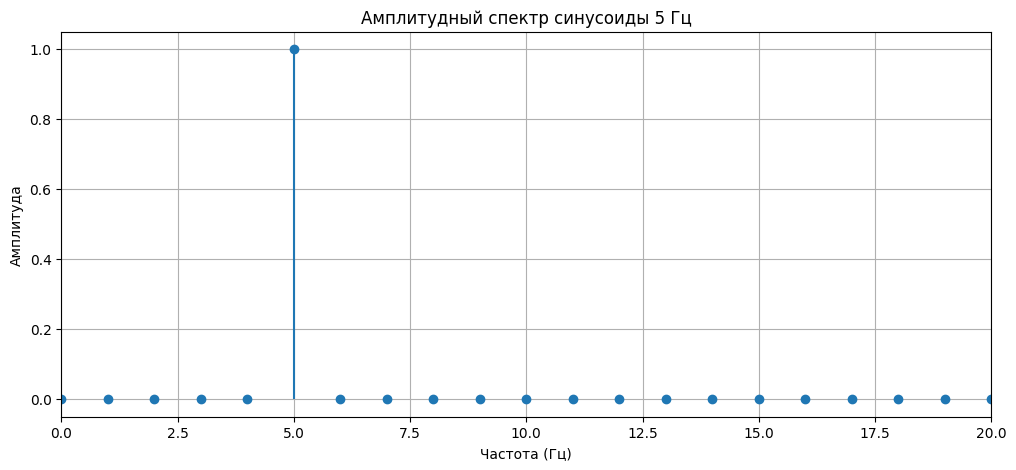

In [4]:
# БПФ синусоиды 5 Гц
X = np.fft.fft(sin5)
freq = np.fft.fftfreq(len(t), d=1/fs)

# Берём только положительные частоты
half = len(t)//2
freq_pos = freq[:half]
X_mag = 2 * np.abs(X[:half]) / len(t)
X_mag[0] /= 2

plt.figure()
plt.stem(freq_pos, X_mag, basefmt=" ", linefmt='C0-', markerfmt='C0o')
plt.title('Амплитудный спектр синусоиды 5 Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 20)
plt.grid(True)
plt.show()


**Вопрос 3:** Почему в спектре присутствует только один пик? Какая должна быть его амплитуда теоретически? Совпадает ли с полученной?

В спектре присутствует только один пик, поскольку сигнал содержит одну частотную составляющую. Его теоретическая амплитуда должна быть равна 1. Она совпадает с полученной, поскольку выполнена корректная нормировка и частота 5 Гц точно попадает в дискретный бин БПФ при длительности 1 с.

### 2.2. Спектр суммы синусоид

Для суммы синусоид (5 и 12 Гц) постройте амплитудный спектр. Убедитесь, что видны два пика на ожидаемых частотах. Измерьте их амплитуды.

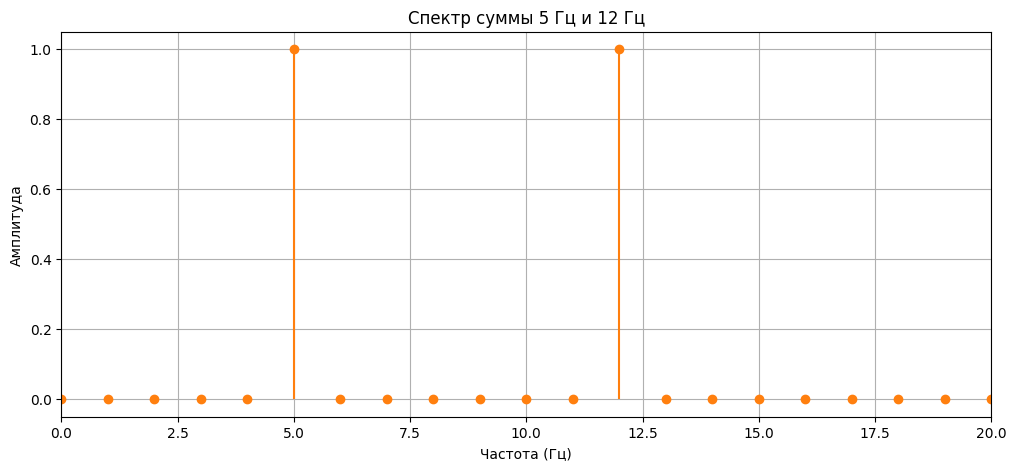

Амплитуда на 5 Гц: 1.0000000000000004
Амплитуда на 12 Гц: 0.9999999999999996


In [5]:
X_sum = np.fft.fft(sum_sin)
X_sum_mag = 2 * np.abs(X_sum[:half]) / len(t)
X_sum_mag[0] /= 2

plt.figure()
plt.stem(freq_pos, X_sum_mag, basefmt=" ", linefmt='C1-', markerfmt='C1o')
plt.title('Спектр суммы 5 Гц и 12 Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 20)
plt.grid(True)
plt.show()

# Амплитуды пиков (для проверки)
print('Амплитуда на 5 Гц:', X_sum_mag[int(5)])
print('Амплитуда на 12 Гц:', X_sum_mag[int(12)])


**Вопрос 4:** Изменится ли амплитудный спектр, если фазы сигналов изменить? Проверьте, задав для одного из них случайную фазу.

Если изменить фазы сигналов, то амплитудный спектр не изменится, т.к. модуль БПФ не зависит от добавления постоянной фазы к синусоиде.

### 2.3. Спектр меандра

Постройте амплитудный спектр меандра частотой 2 Гц. Сравните с теоретическим представлением: меандр состоит из нечётных гармоник с убывающими амплитудами $(1, 1/3, 1/5,\dots)\cdot 4/\pi$.

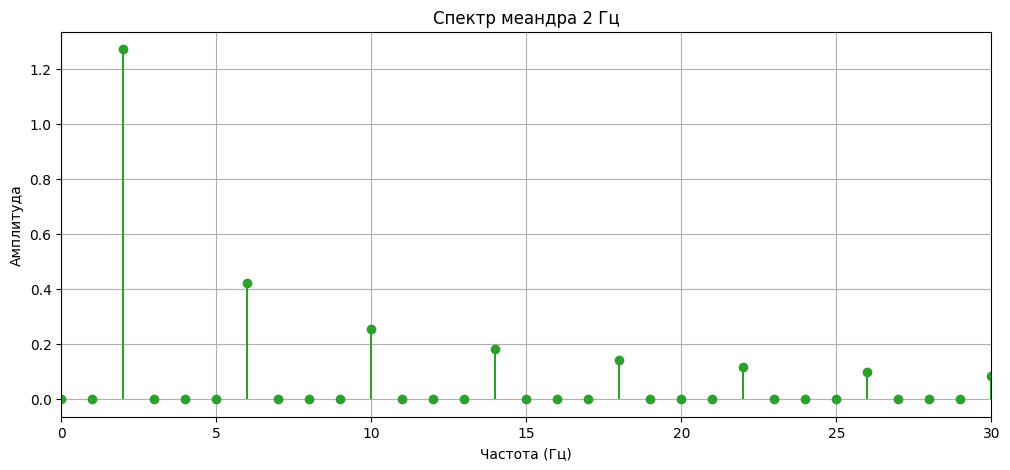

In [6]:
X_meander = np.fft.fft(meander)
X_meander_mag = 2 * np.abs(X_meander[:half]) / len(t)
X_meander_mag[0] /= 2

plt.figure()
plt.stem(freq_pos, X_meander_mag, basefmt=" ", linefmt='C2-', markerfmt='C2o')
plt.title('Спектр меандра 2 Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 30)
plt.grid(True)
plt.show()



**Вопрос 5:** Почему в спектре меандра присутствуют только нечётные гармоники? Покажите, что амплитуды гармоник совпадают с теоретическим значением.

В спектре присутствуют только нечётные гармоники, поскольку у меандра есть полуволновая антисимметрия (и в его разложении Фурье чётные гармоники взаимно компенсируются).

Вычислим теоретические амплитуды нескольких первых гармоник: для $n=1,3,5,7,9$ (гармоники на частотах $2n$ Гц) $[1.27324,\ 0.42441,\ 0.25465,\ 0.18189,\ 0.14147]$.

При численном вычислении Фурье-преобразования получились следующие значения амплитуд гармоник: $[1.27325,\ 0.42444,\ 0.25469,\ 0.18195,\ 0.14155]$.

Видим, что результаты вычислений совпадают с теоретическими значениями.

## Часть 3. Дискретизация и алиасинг

### 3.1. Корректная и некорректная дискретизация

Создайте «аналоговый» сигнал — синусоиду частотой 8 Гц, но с очень высокой частотой дискретизации (например, 1000 Гц), чтобы он выглядел гладким.

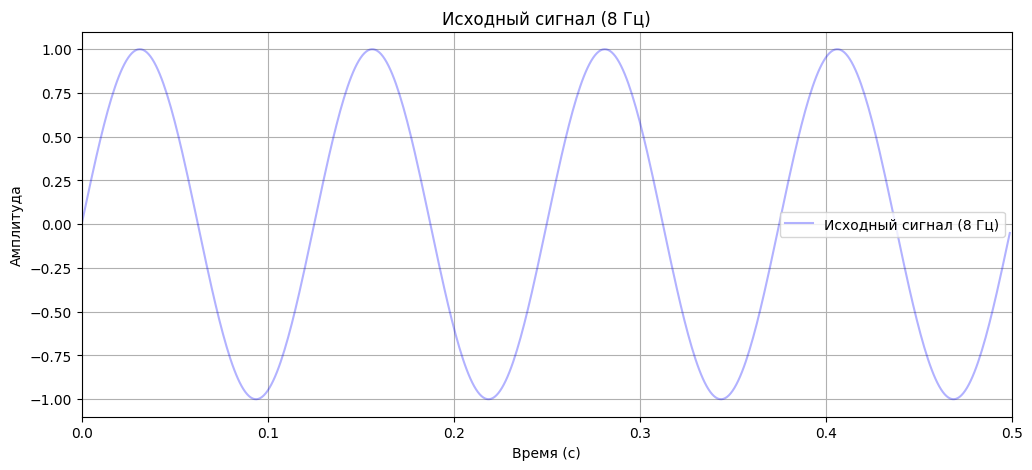

In [7]:
# «Аналоговый» сигнал с высокой частотой дискретизации
fs_analog = 1000
T_view = 0.5

t_analog = np.linspace(0, T_view, int(fs_analog * T_view), endpoint=False)
f_signal = 8
analog_signal = np.sin(2 * np.pi * f_signal * t_analog)

plt.figure(figsize=(12,5))
plt.plot(t_analog, analog_signal, 'b-', alpha=0.3, label='Исходный сигнал (8 Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Исходный сигнал (8 Гц)')
plt.legend()
plt.grid(True)
plt.xlim(0, 0.5)
plt.show()


Теперь выполните его дискретизацию с двумя разными частотами:
- $f_{s1} = 50$ Гц (заведомо больше удвоенной частоты сигнала, 2·8=16 Гц);
- $f_{s2} = 12$ Гц (меньше 16 Гц).

Для этого создайте новые временные оси с шагом $1/f_{s1}$ и $1/f_{s2}$ и вычислите значения синусоиды в этих точках.

На одном графике изобразите:
- исходный гладкий сигнал (тонкая линия);
- отсчёты при корректной дискретизации (маркеры);
- отсчёты при алиасинге (маркеры другого цвета).

Также постройте сигнал, который «воспринимается» после дискретизации с малой частотой.

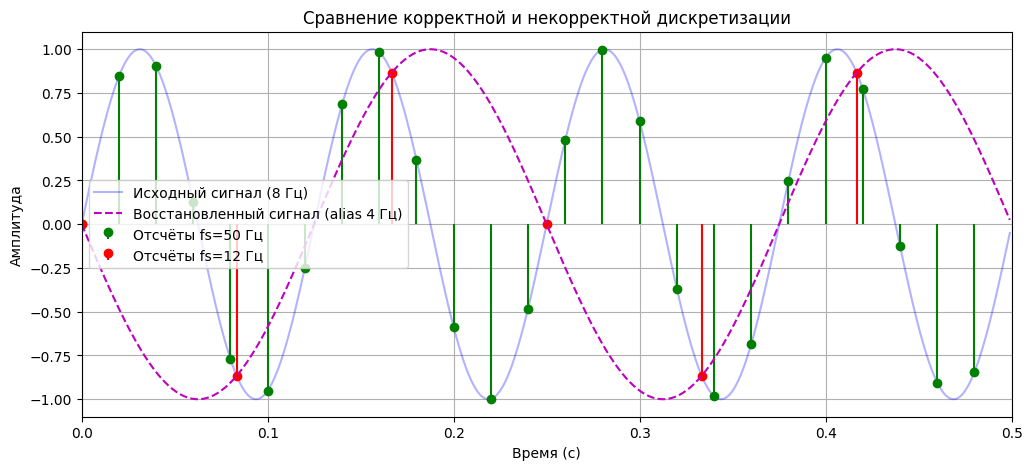

k = 1 , f_alias = 4


In [8]:
# Частоты дискретизации для эксперимента
fs1 = 50
fs2 = 12

# Отсчёты при корректной дискретизации
t1 = np.arange(0, T_view, 1/fs1)
samples1 = np.sin(2 * np.pi * f_signal * t1)

# Отсчёты при некорректной дискретизации (алиасинг)
t2 = np.arange(0, T_view, 1/fs2)
samples2 = np.sin(2 * np.pi * f_signal * t2)

# Алиасная частота в диапазоне [0, fs/2]
k = int(np.floor(f_signal / fs2 + 0.5))
f_res = f_signal - k * fs2
f_alias = abs(f_res)
reconstructed = np.sign(f_res) * np.sin(2 * np.pi * f_alias * t_analog) if f_alias != 0 else np.zeros_like(t_analog)

plt.figure(figsize=(12,5))
plt.plot(t_analog, analog_signal, 'b-', alpha=0.3, label='Исходный сигнал (8 Гц)')
plt.stem(t1, samples1, linefmt='g-', markerfmt='go', basefmt=' ', label=f'Отсчёты fs={fs1} Гц')
plt.stem(t2, samples2, linefmt='r-', markerfmt='ro', basefmt=' ', label=f'Отсчёты fs={fs2} Гц')
plt.plot(t_analog, reconstructed, 'm--', label=f'Восстановленный сигнал (alias {f_alias:g} Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Сравнение корректной и некорректной дискретизации')
plt.legend()
plt.grid(True)
plt.xlim(0, 0.5)
plt.show()

print('k =', k, ', f_alias =', f_alias)


**Вопрос 6:** Какая частота «кажется» присутствующей в сигнале при $f_{s2}=12$ Гц? Совпадает ли она с предсказанной теоретически? (Подсказка: формула алиасинга $f_{alias} = |f - k f_s|$, выберите $k$ так, чтобы $f_{alias}$ лежала в интервале $[0, f_s/2]$.)

В сигнале при $f_{s2}=12$ Гц кажется, что присутствует частота 4 Гц. Она совпадает с теоретической: $f_{alias} = |f - k f_s| = 4$ при $k=1$.

### 3.2. Интерактивная демонстрация алиасинга

Используя `ipywidgets.interact`, создайте интерактивный график, где можно менять частоту сигнала и частоту дискретизации ползунками, и сразу видеть исходный сигнал, отсчёты и восстановленный сигнал. Пример такого кода был на лекции.

Добейтесь, чтобы при нарушении условия Найквиста явно проявлялся алиасинг (восстановленный сигнал имел более низкую частоту, чем исходный).

In [9]:
def plot_aliasing(f_signal, f_sampling):
    T_view = 0.5
    t_hi = np.linspace(0, T_view, 2000, endpoint=False)

    x_true = np.sin(2 * np.pi * f_signal * t_hi)

    # Отсчёты
    t_s = np.arange(0, T_view, 1/f_sampling)
    x_s = np.sin(2 * np.pi * f_signal * t_s)

    # Алиасная частота (в полосе [0, fs/2])
    k = int(np.floor(f_signal / f_sampling + 0.5))
    f_res = f_signal - k * f_sampling
    f_alias = abs(f_res)
    x_rec = np.sign(f_res) * np.sin(2 * np.pi * f_alias * t_hi) if f_alias != 0 else np.zeros_like(t_hi)

    plt.figure(figsize=(12,4))
    plt.plot(t_hi, x_true, 'b-', alpha=0.3, label='Исходный сигнал')
    plt.stem(t_s, x_s, linefmt='r-', markerfmt='ro', basefmt=' ', label='Отсчёты')
    plt.plot(t_hi, x_rec, 'm--', label=f'Восстановленный (alias {f_alias:g} Гц)')
    plt.xlabel('Время (с)')
    plt.ylabel('Амплитуда')
    plt.title(f'Частота сигнала = {f_signal:g} Гц, fs = {f_sampling:g} Гц')
    plt.legend()
    plt.grid(True)
    plt.xlim(0, 0.5)
    plt.show()

widgets.interact(
    plot_aliasing,
    f_signal=widgets.FloatSlider(min=0.5, max=30.0, step=0.5, value=8.0),
    f_sampling=widgets.FloatSlider(min=5.0, max=60.0, step=1.0, value=12.0),
);


interactive(children=(FloatSlider(value=8.0, description='f_signal', max=30.0, min=0.5, step=0.5), FloatSlider…

**Вопрос 7:** При каких соотношениях частоты сигнала и частоты дискретизации алиасинг наиболее заметен? Что происходит, когда частота сигнала в точности равна половине частоты дискретизации?

Алиасинг наиболее заметен, когда $f > f_s/2$, и особенно когда $f$ близка к $f_s/2$: тогда восстановленный сигнал может выглядеть как синусоида заметно более низкой частоты.

Когда частота сигнала в точности равна половине частоты дискретизации, то получается всего два отсчёта на период. Для $\sin(2\pi\cdot (f_s/2)\, t)$ при нулевой фазе это даёт $\sin(\pi n)=0$ для всех $n$ (все отсчёты нулевые), а при другой фазе - чередование двух значений.